# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


## last Five row

In [4]:
df.tail()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
10340,10341,52,Student,17344.34,393,5000.00,Fashion,6,0,0,1,4.33,USA,2024-10-25,0.288278,182.8,High Risk
10341,10342,53,Student,17788.20,300,100.00,Sports,12,12,1,0,1.41,Australia,2023-06-15,0.005622,264.0,High Risk
10342,10343,42,Self-Employed,59350.25,535,5000.00,Home,12,4,2,0,5.07,Australia,2024-09-24,0.084246,174.0,High Risk
10343,10344,59,Self-Employed,73739.74,678,5000.00,Beauty,3,2,0,0,8.89,Germany,2023-01-19,0.067806,72.8,Medium Risk
10344,10345,23,Unemployed,6345.21,360,1015.57,Sports,9,0,0,1,3.10,India,2024-07-09,0.160053,196.0,High Risk


## Shape of our dataset

In [5]:
df.shape

(10345, 17)

## List out all columns

In [6]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

user_id                   int64
age                       int64
employment_type          object
monthly_income          float64
credit_score              int64
purchase_amount         float64
product_category         object
bnpl_installments         int64
repayment_delay_days      int64
missed_payments           int64
default_flag              int64
app_usage_frequency     float64
location                 object
transaction_date         object
debt_to_income_ratio    float64
risk_score              float64
customer_segment         object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

## Check Null Value

In [9]:
df.isnull().sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

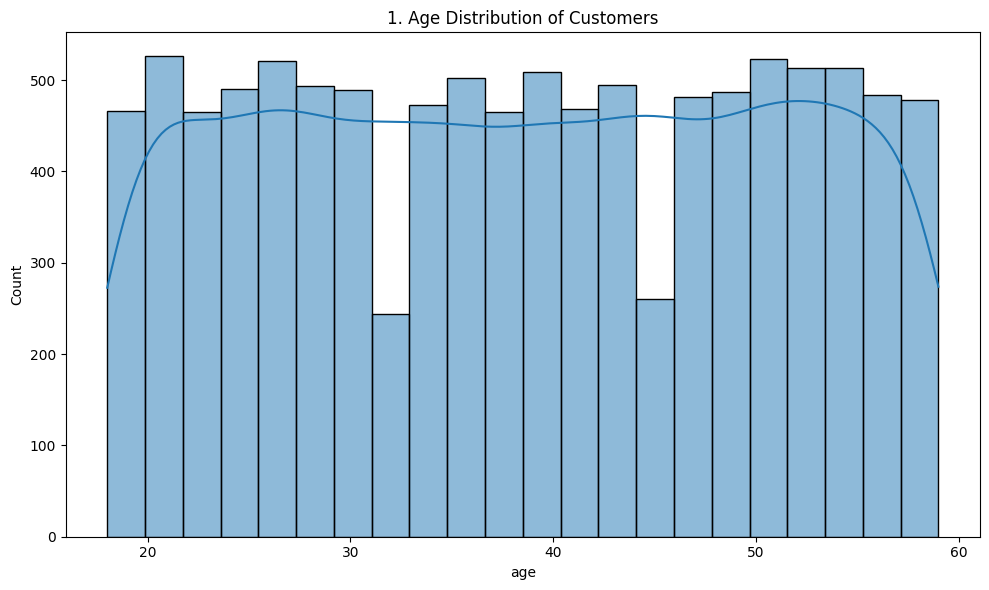

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Customers')
show_fig()
plot_no += 1

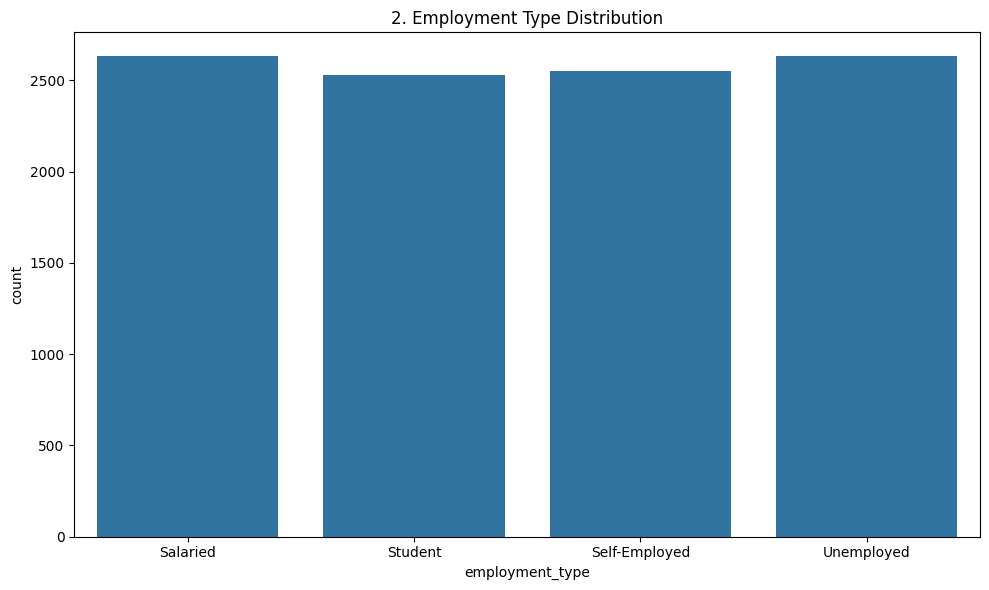

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='employment_type', data=df)
plt.title(f'{plot_no}. Employment Type Distribution')
show_fig()
plot_no += 1

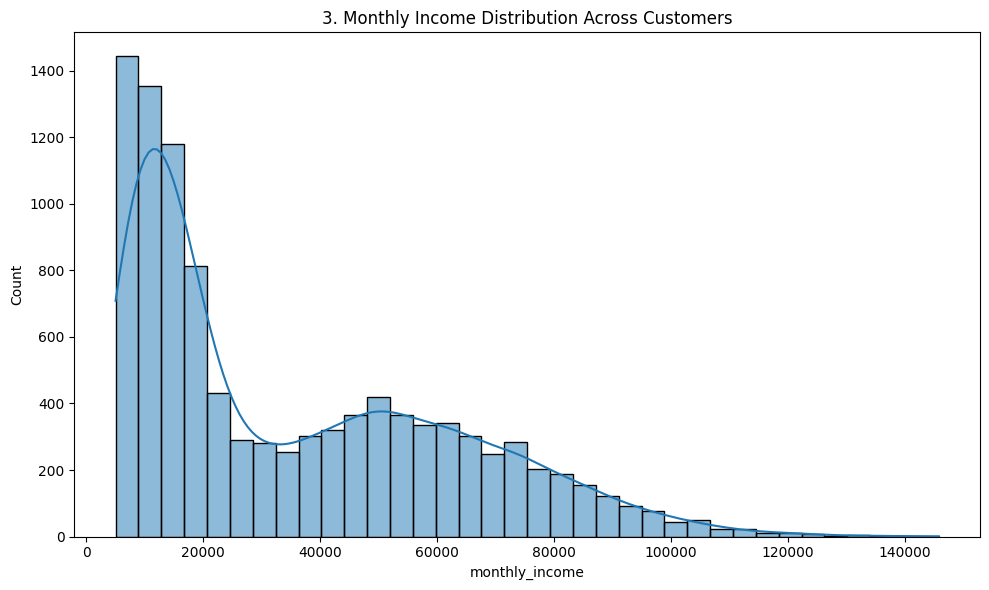

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['monthly_income'], kde=True)
plt.title(f'{plot_no}. Monthly Income Distribution Across Customers')
show_fig()
plot_no += 1

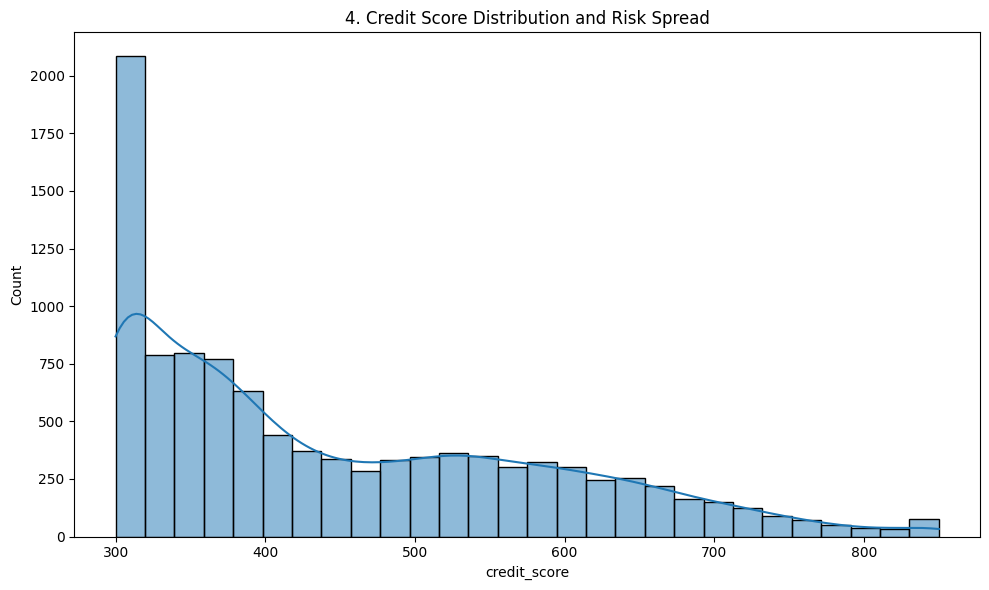

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['credit_score'], kde=True)
plt.title(f'{plot_no}. Credit Score Distribution and Risk Spread')
show_fig()
plot_no += 1

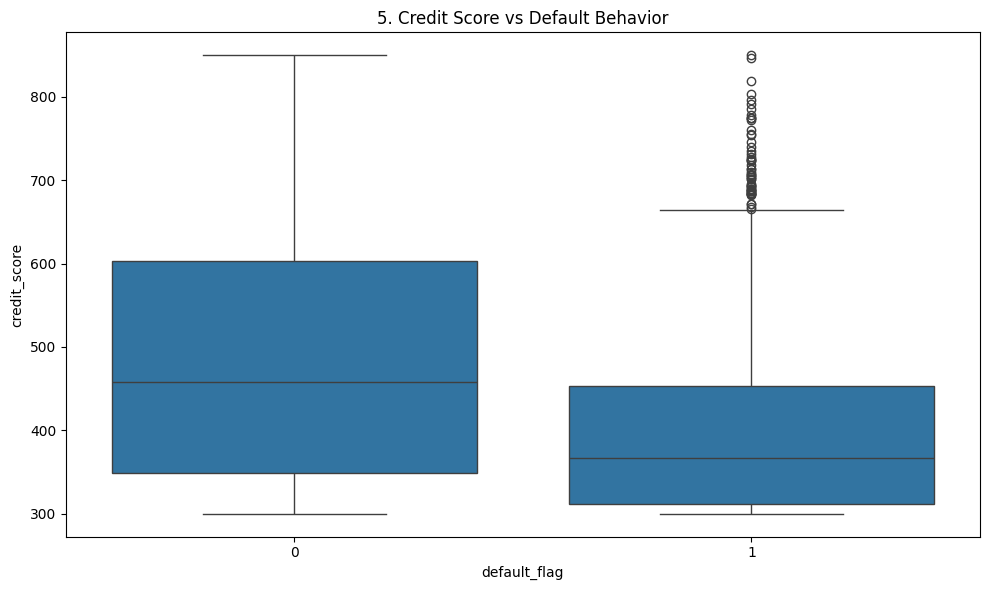

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='default_flag', y='credit_score', data=df)
plt.title(f'{plot_no}. Credit Score vs Default Behavior')
show_fig()
plot_no += 1

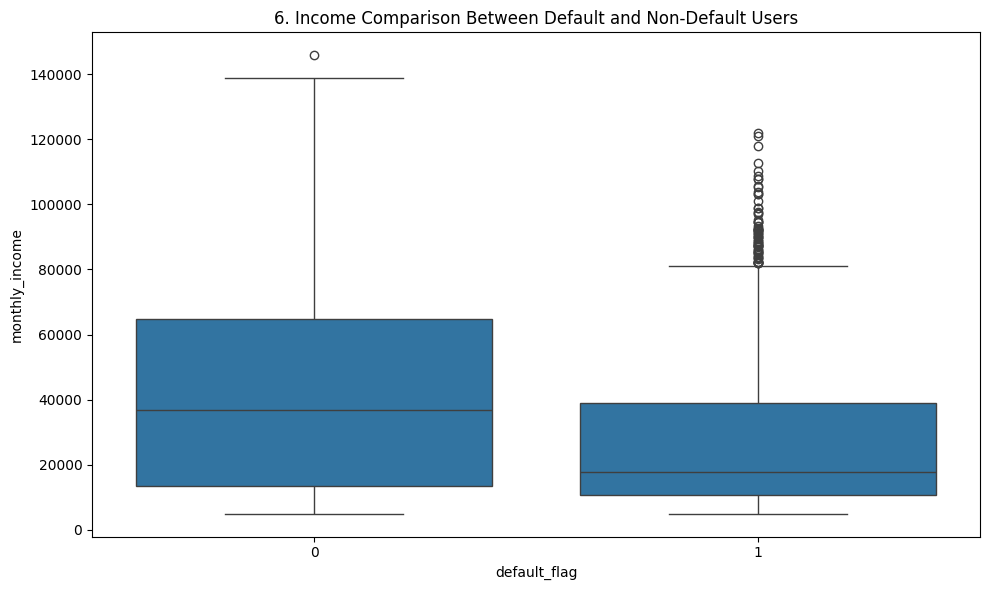

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='default_flag', y='monthly_income', data=df)
plt.title(f'{plot_no}. Income Comparison Between Default and Non-Default Users')
show_fig()
plot_no += 1

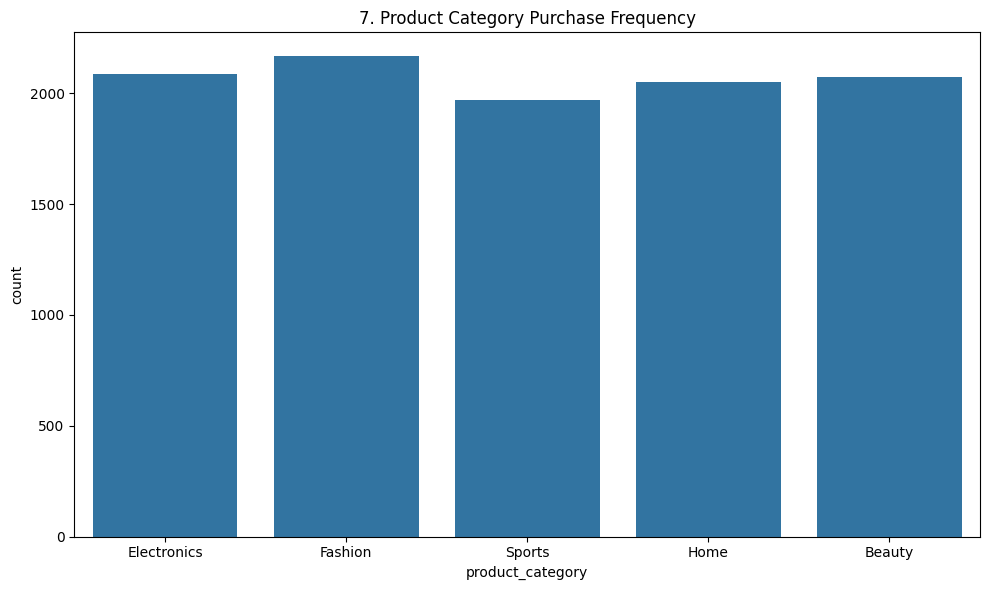

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='product_category', data=df)
plt.title(f'{plot_no}. Product Category Purchase Frequency')
show_fig()
plot_no += 1

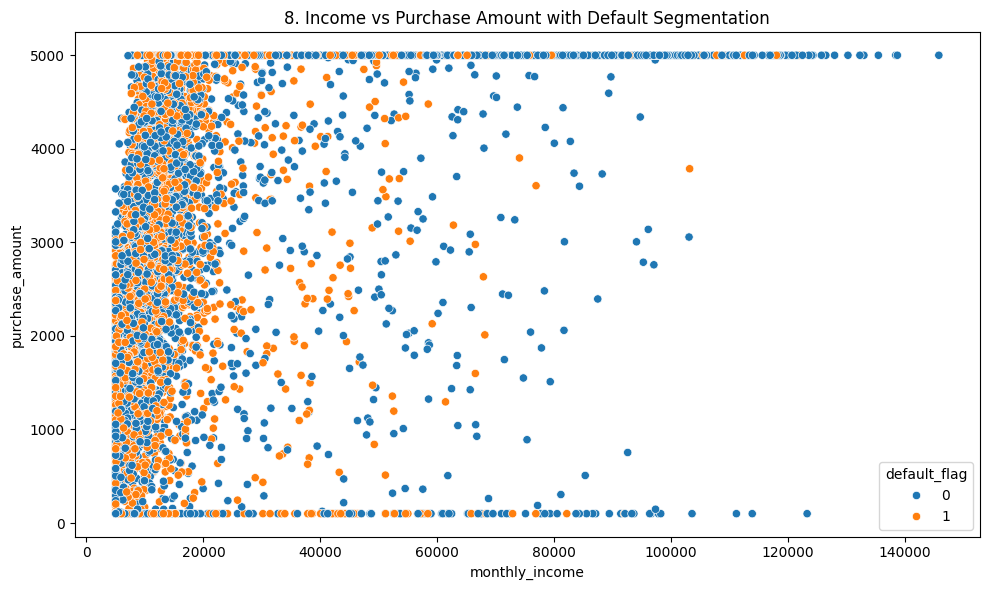

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='monthly_income', y='purchase_amount', hue='default_flag', data=df)
plt.title(f'{plot_no}. Income vs Purchase Amount with Default Segmentation')
show_fig()
plot_no += 1

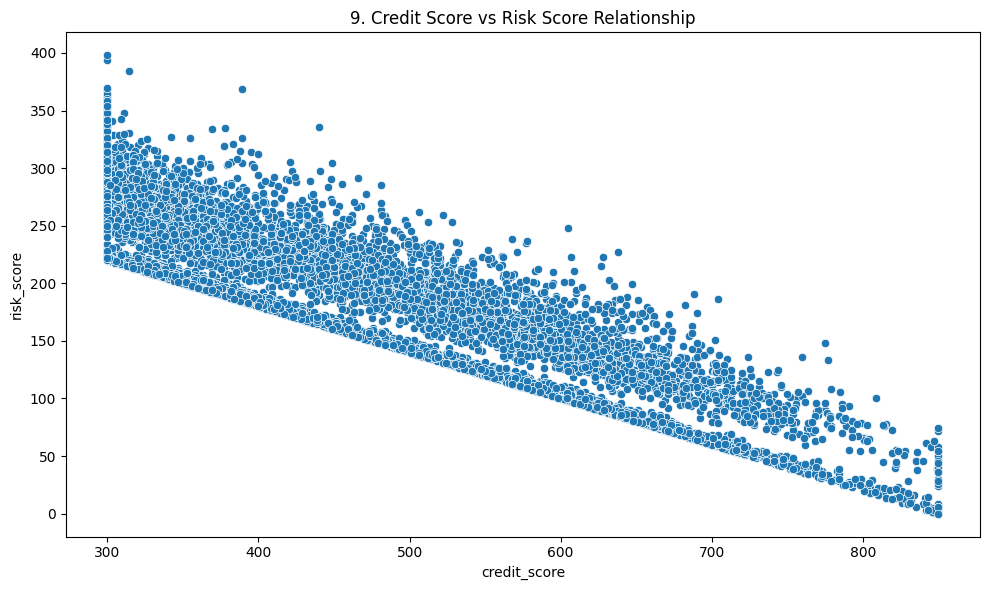

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='credit_score', y='risk_score', data=df)
plt.title(f'{plot_no}. Credit Score vs Risk Score Relationship')
show_fig()
plot_no += 1

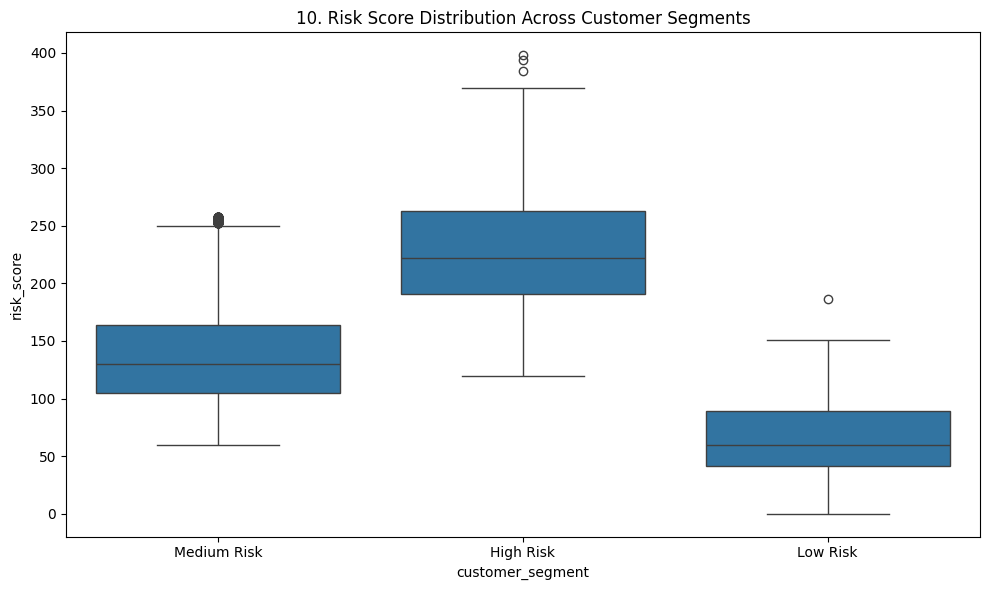

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='customer_segment', y='risk_score', data=df)
plt.title(f'{plot_no}. Risk Score Distribution Across Customer Segments')
show_fig()
plot_no += 1

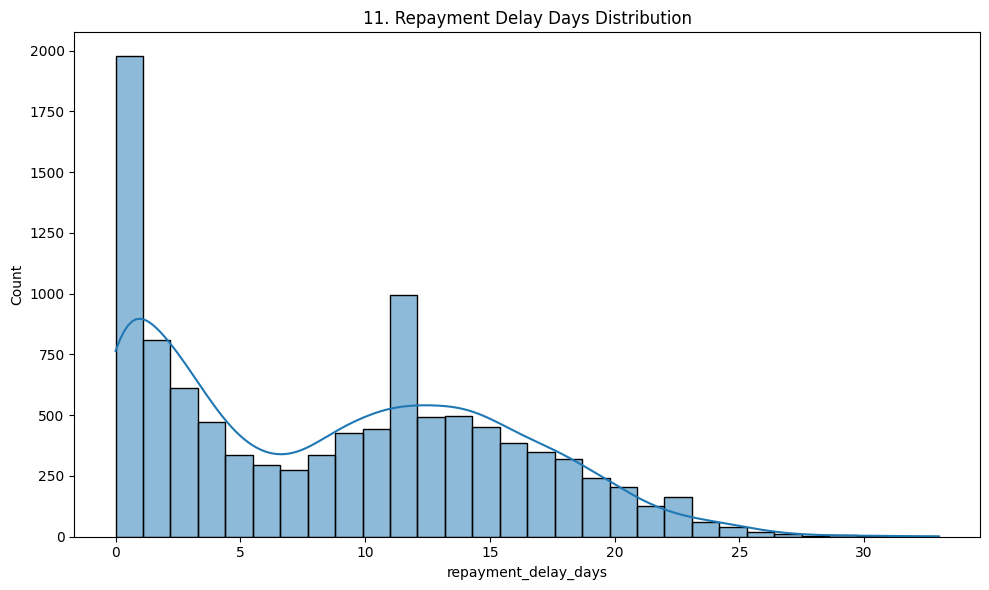

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['repayment_delay_days'], kde=True)
plt.title(f'{plot_no}. Repayment Delay Days Distribution')
show_fig()
plot_no += 1

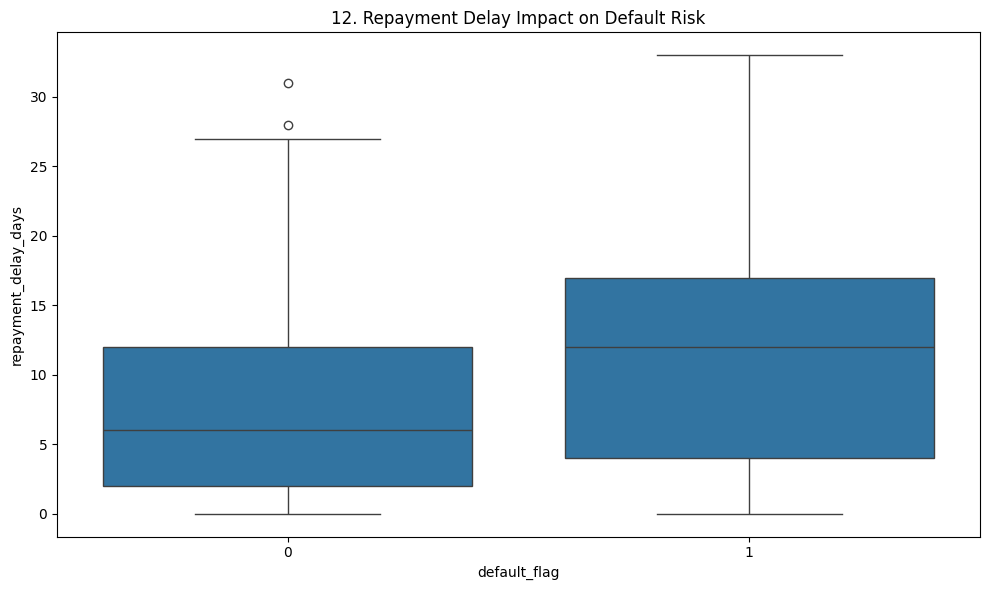

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='default_flag', y='repayment_delay_days', data=df)
plt.title(f'{plot_no}. Repayment Delay Impact on Default Risk')
show_fig()
plot_no += 1

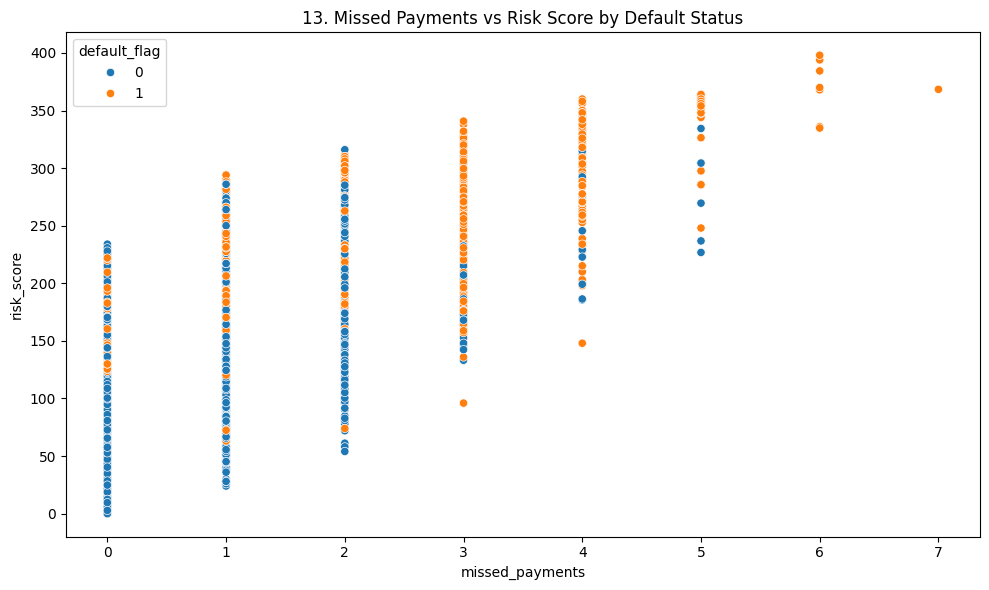

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='missed_payments', y='risk_score', hue='default_flag', data=df)
plt.title(f'{plot_no}. Missed Payments vs Risk Score by Default Status')
show_fig()
plot_no += 1

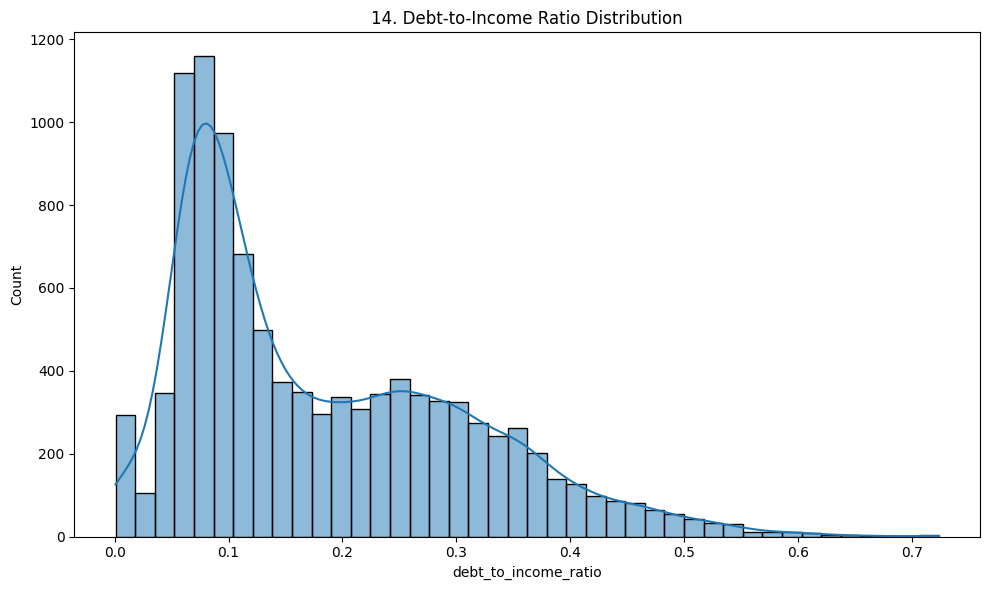

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['debt_to_income_ratio'], kde=True)
plt.title(f'{plot_no}. Debt-to-Income Ratio Distribution')
show_fig()
plot_no += 1

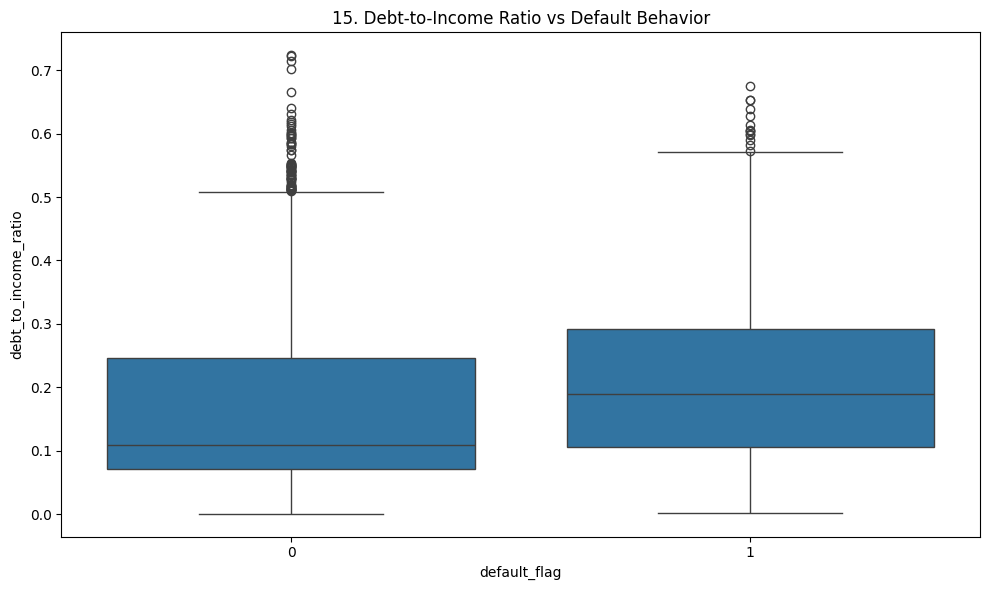

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='default_flag', y='debt_to_income_ratio', data=df)
plt.title(f'{plot_no}. Debt-to-Income Ratio vs Default Behavior')
show_fig()
plot_no += 1

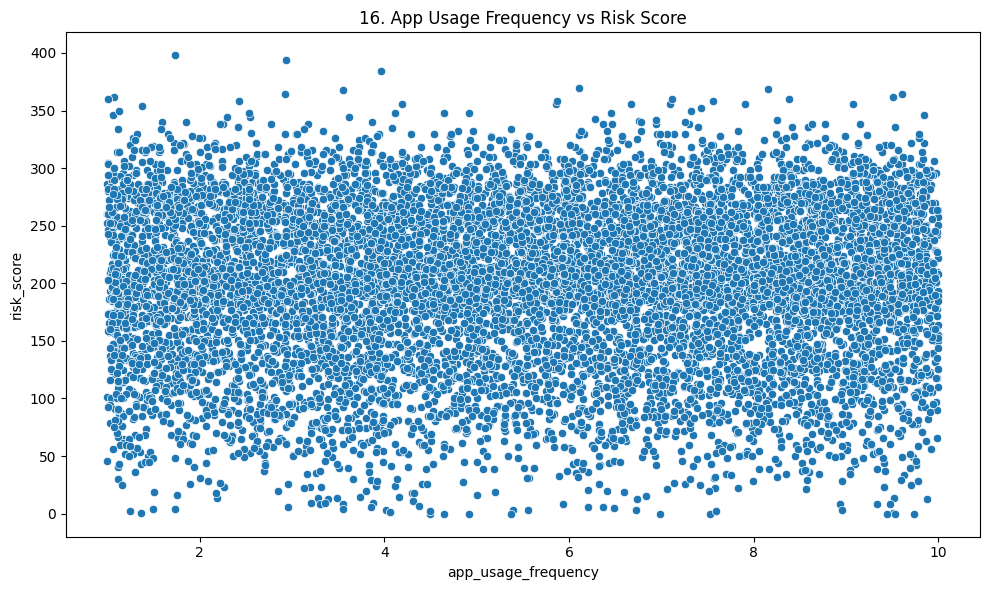

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='app_usage_frequency', y='risk_score', data=df)
plt.title(f'{plot_no}. App Usage Frequency vs Risk Score')
show_fig()
plot_no += 1

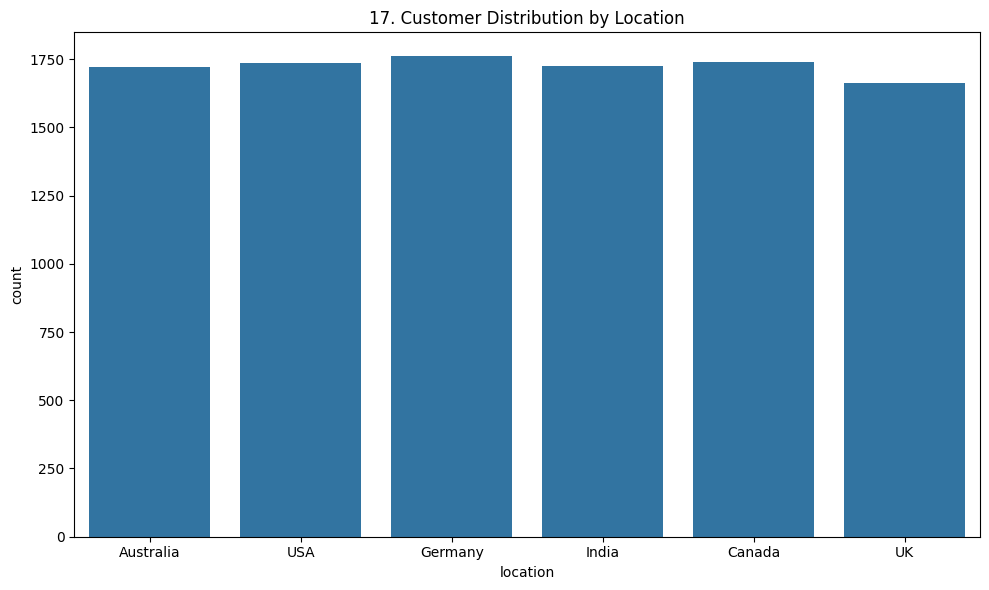

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='location', data=df)
plt.title(f'{plot_no}. Customer Distribution by Location')
show_fig()
plot_no += 1

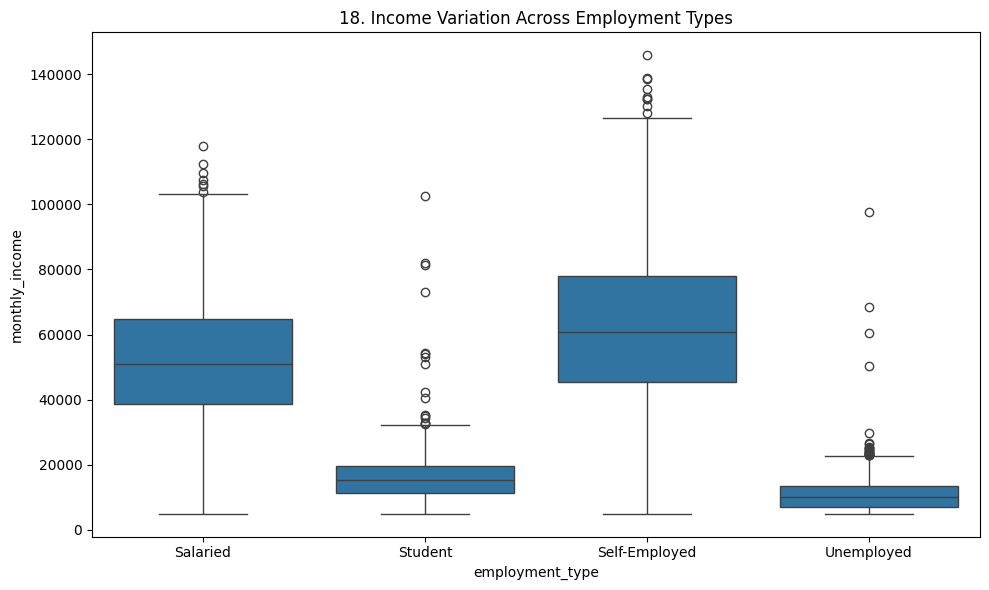

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='employment_type', y='monthly_income', data=df)
plt.title(f'{plot_no}. Income Variation Across Employment Types')
show_fig()
plot_no += 1

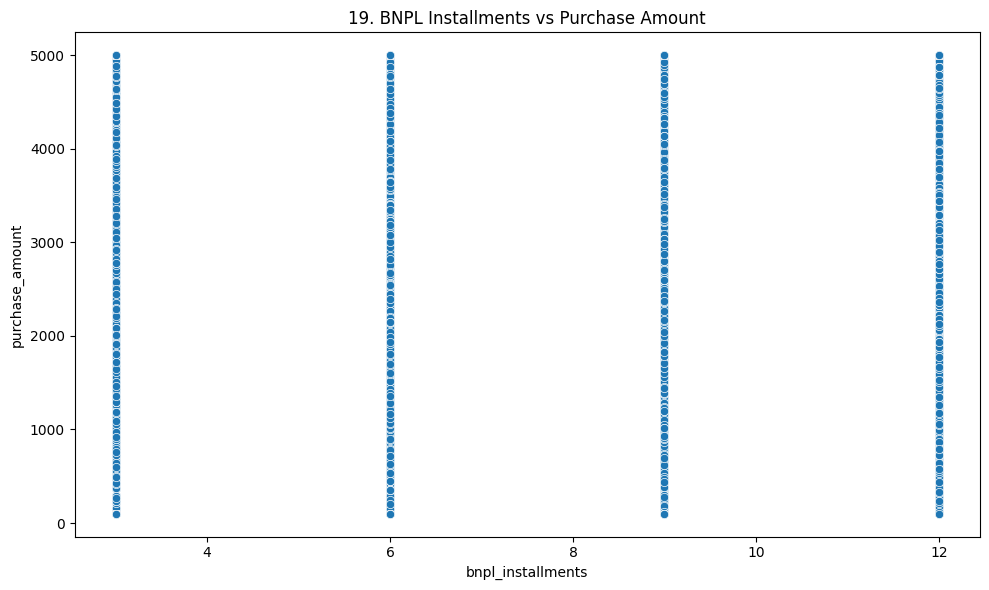

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='bnpl_installments', y='purchase_amount', data=df)
plt.title(f'{plot_no}. BNPL Installments vs Purchase Amount')
show_fig()
plot_no += 1

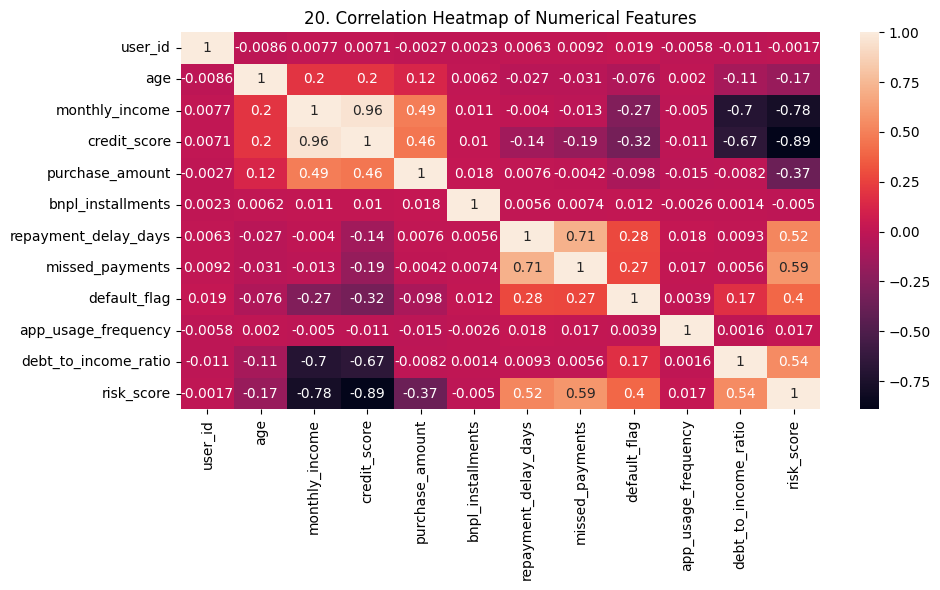

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## feature engineering for better performance

In [33]:
df['payment_risk'] = df['missed_payments'] + df['repayment_delay_days']
df['income_to_credit'] = df['monthly_income'] / (df['credit_score'] + 1)

## select important features

In [34]:
X = df[['monthly_income','credit_score','purchase_amount',
        'repayment_delay_days','missed_payments',
        'debt_to_income_ratio','risk_score',
        'payment_risk','income_to_credit']]
y = df['default_flag']

## split data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scaling

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train advanced model

In [37]:
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3)
model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## predictions

In [38]:
y_pred = model.predict(X_test)

## print accuracy

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7182213629772837


## confusion matrix

<Figure size 1000x600 with 0 Axes>

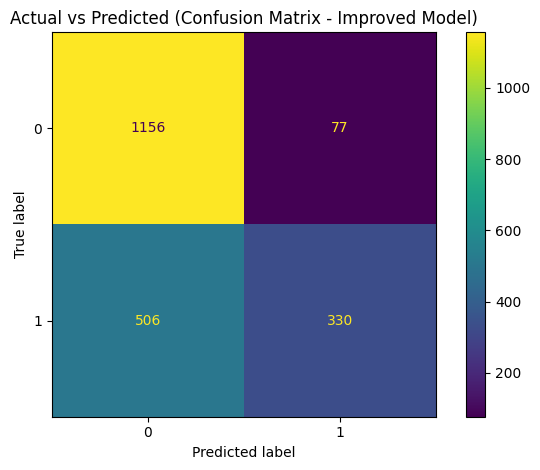

In [40]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Actual vs Predicted (Confusion Matrix - Improved Model)')
plt.tight_layout()
plt.show()